# Consigna

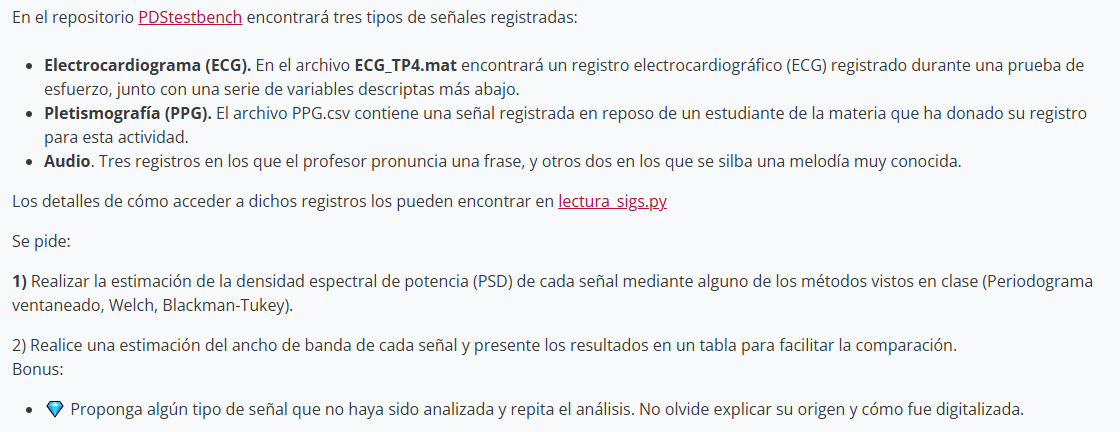

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    '''power(x: np.ndarray) -> float:
        Returns the power of the signal x, defined as the mean of the square of the Voltage signal. 
    '''
    return np.mean(np.mean(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

En este trabajo práctico analizaremos métodos alternativos a la FFT para el análisis espectral. Estos métodos no paramétricos están pensados para disminuir la varianza por lo que se utilizarán señales reales (sin ruido pero reales) en contra de las sintetizadas por código como hacíamos anteriormente.

### Señales a procesar
A continuación, se anotan todas las señales a procesar. Estas son:

* ECG: Muestra de un Electrocardiograma.
* PPG: Muestra de una Fotopletismografía.
* WAV: Archivo de audio con la cucaracha.

In [2]:
import scipy.io as sio
import scipy.signal as sig

import matplotlib.pyplot as plt

## Imprime dentro de VSCode:
# %matplotlib widget      
## Imprime en una pestaña a parte
# %matplotlib qt        

In [3]:
####### Señales 

## Electrocardiograma
fs_ecg = 1000 # Hz
ecg_data = np.load(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\ecg_sin_ruido.npy')

## Fotopletismografía
fs_ppg = 400 # Hz
ppg_data = np.load(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\ppg_sin_ruido.npy')

## Audio
fs_wav, wav_data = sio.wavfile.read(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\la cucaracha.wav')

## Lista completa
signals = {
    "ecg": {"fs": fs_ecg, "data": ecg_data },
    "ppg": {"fs": fs_ppg, "data": ppg_data },
    "wav": {"fs": fs_wav, "data": wav_data }
}

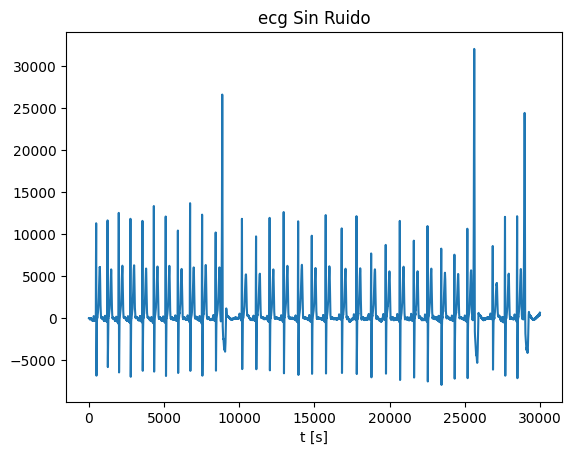

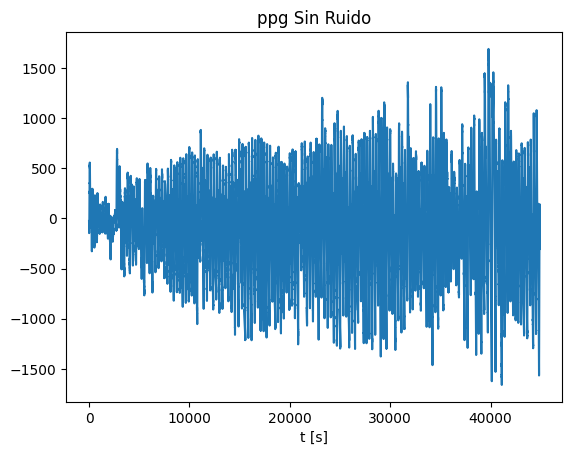

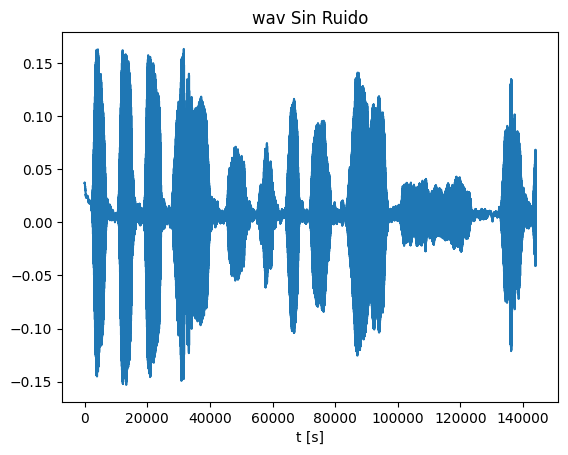

In [4]:
## Gráfico temporal de las señales

for name, signal in signals.items():
    plt.figure()
    plt.plot(signal["data"])
    plt.xlabel("t [s]")
    plt.title(f"{name} Sin Ruido")
    plt.show()

### Peridograma ventaneado

El algoritmo de periodograma corresponde al mismo que una FFT tradicional.
Se realizarán las mismas pruebas que antes con el algoritmo FFT.

Importante: Por temas de comparación con los otros 2 métodos, se eliminará la media de la señal (la componente de continua).
Esto se debe a que los otros métodos (el blackman tukey en particular) no funcionan correctamente si no se la elimina, resultando en comparaciones disparejas.

In [5]:
def periodograma_ventaneado(x, fs, nfft = None):
    N = len(x)
    x = x - np.mean(x)
    
    if nfft is None:
        nfft = N

    win = sig.windows.blackman(N)
    U = np.mean(win**2)

    Pxx_ = np.fft.rfft(x*win, n=nfft)
    Pxx_ =  np.abs(Pxx_)**2
    Pxx_[1:-1] *= 2
    Pxx_ /= N*U*fs 

    f_ = np.fft.rfftfreq(2*N, d = 1/fs) 

    return f_, Pxx_


N de ecg: 30000


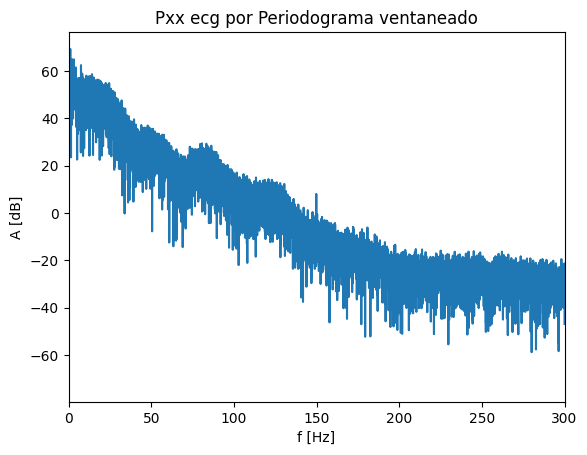

N de ppg: 44919


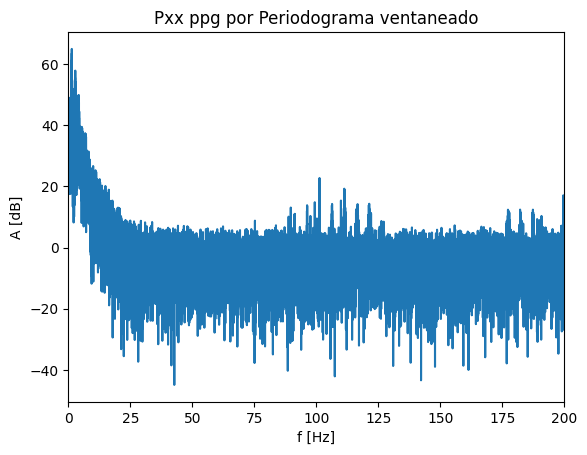

N de wav: 144000


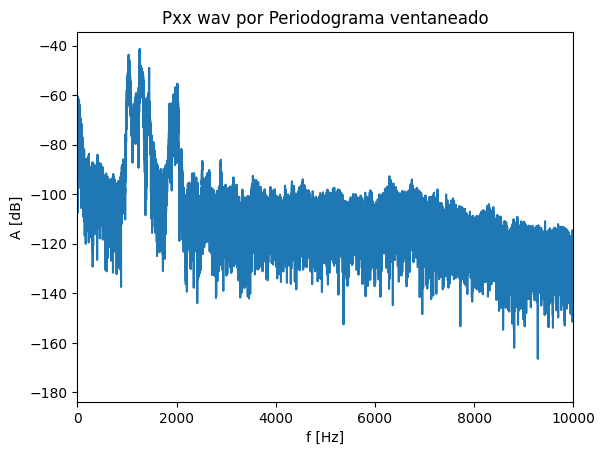

In [6]:
xlim = { "ecg":300, "ppg":200, "wav":10e3 }

for name, signal in signals.items():
    N = len(signal["data"])
    print(f"N de {name}: {N}")
    win = sig.windows.blackman(N)
    win /= np.mean(win)

    plt.figure()
    plt.title(f"Pxx {name} por Periodograma ventaneado")

    # Calculo del periodograma/FFT
    f_, Pxx_ = periodograma_ventaneado(signal["data"], nfft=2*N, fs= signal["fs"])
    
    #f_, Pxx_ = sig.periodogram(signal["data"], nfft=2*N, fs= signal["fs"], window='blackman')

    signal["periodograma"] = Pxx_
    signal["f_periodograma"] = f_

    plt.plot(f_, 10*np.log10(np.abs(Pxx_)))
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")
    plt.show()


No hay nada nuevo que explicar acá. Se realizó la FFT de una señal con zero-padding (Nfft = 2*N) utilizando la ventana blackman. Podría utilizarse otra ventana o ajustar el zero-padding para mejorar la salida en función de lo que se desea medir.


### Welch

Comenzaremos probando el algoritmo de Welch con 3 señales sin ruido.

El algoritmo, en concepto, realiza múltiples FFT en pedazos de la señal. Estos segmentos son de un tamaño "nperseg". La cantidad de segmentos K se puede definir como K = N/nperseg, siendo N la cantidad total de muestras.
Además, estos segmentos pueden estar solapados entre sí. Esto se define como noverlap y se utilizará el default de la función.

Ahora realizaremos el mismo algoritmo con el doble de muestras (zero padding) y probaremos el resultado con distintos valores de K.


In [7]:
K = [2, 5, 10, 15, 20]

N de ecg: 30000


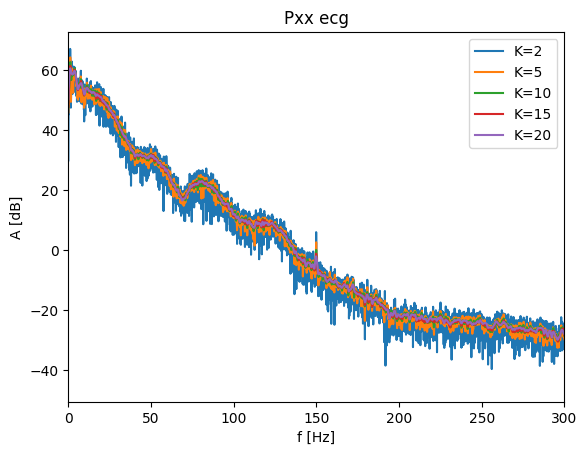

N de ppg: 44919


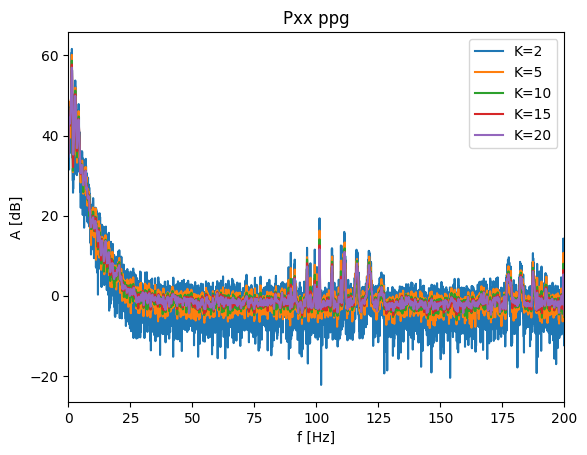

N de wav: 144000


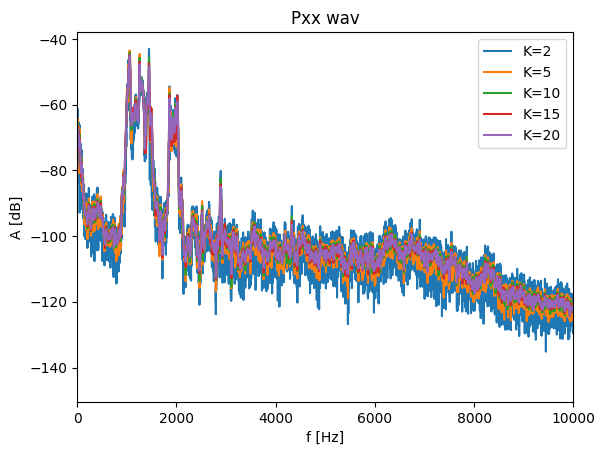

In [8]:
xlim = { "ecg":300, "ppg":200, "wav":10e3 }

for name, signal in signals.items():
    N = len(signal["data"])
    print(f"N de {name}: {N}")

    plt.figure()
    plt.title(f"Pxx {name}")
    for k in K:
        f_, Pxx_ = sig.welch(signal["data"], fs=signal["fs"], nperseg=N/k, nfft= 2*N)
        plt.plot(f_, 10*np.log10(np.abs(Pxx_)), label=f"K={k}")
    plt.legend()
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")
    plt.show()


Se puede observar, al realizar zoom a las señales, que un mayor K genera una señal más suave y un K menor genera mayores oscilaciones.

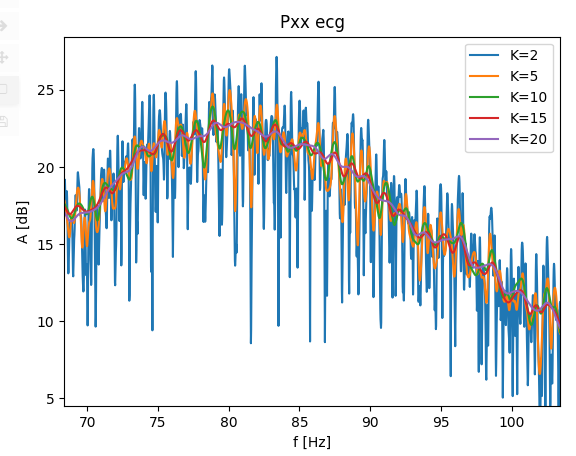
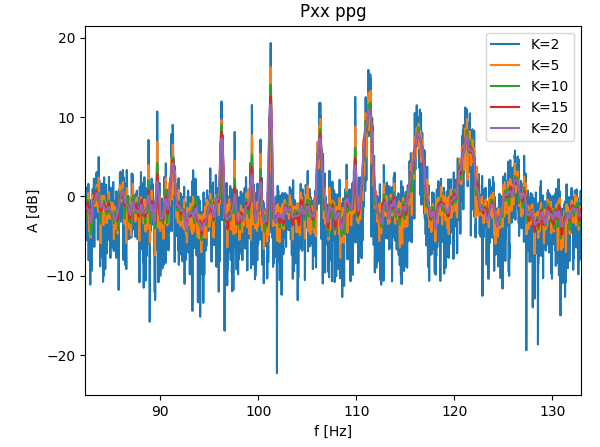
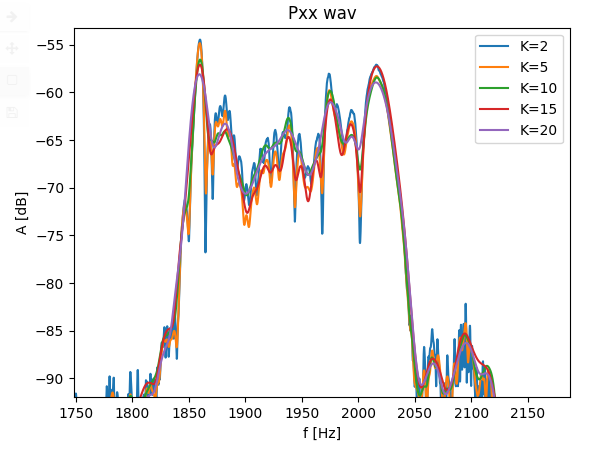

El suavizado, para grandes K puede alejarse de los valores. Se debe estimar un valor de K óptimo mediante intuición.

Se considera correcto en estos ejemplos, un K=15 para el trabajo de las señales. Elegir otro valor es totalmente válido y podría realizarse el estudio con otro K

In [9]:
for name, signal in signals.items():
    N = len(signal["data"])
    f_, Pxx_ = sig.welch(signal["data"], fs=signal["fs"], nperseg= N/15, nfft=2*N)
    signal["welch"] = Pxx_
    signal["f_welch"] = f_

### Blackman Tuck

Se debe definir el algoritmo, puesto que scipy no lo tiene.

Al utiizar el algoritmo de Welch la información se separaba en K segmentos y luego se los promediaba. Estos segmentos a su vez podían estar solapados entre sí. Se puede intuir que, al calcular la autocorrelación y tener segmentos separados, los datos que se encuentran en los bordes se utilizan muchisimo menos que los datos que se encuentran en el centro. Estos datos de los bordes pueden llevar a un resultado mucho menos promediado, elevando la varianza del resultado final. Blackman Tukey parte de este concepto y aplica una ventana a la autocorrelación para eliminar dichos valores extremos. 

El método de Blackman Tukey posee los siguientes pasos:
1. Cálculo de la autocorrelación.
2. Aplicación de la ventana.
3. Cálculo de la FFT de la autocorrelación (ya ventaneada).


El algoritmo de Blackman Tukey presenta la siguiente forma:

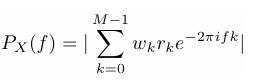

donde:

* wk: ventana (Blackman, Bartlett, etc.).
* M: máximo lag usado.
* rk: Autocorrelación.


In [10]:
def my_blackman_tukey(x, fs = 1, M = None, nfft = None):
    N = np.max(x.shape)     # Cant muestras

    if nfft is None:
        nfft = N
    if M is None:
        M = N//5

    x = x - np.mean(x)

    # 1. Correación    
    r = sig.correlate(x, x, mode='full') / N
    r = r[N-M-1 : N+M]
    # Nota: correlate devuelve un vector de 2N-1. Yo quiero uno de 2M+1, centrado. Debo quitarle las puntas
    #       Las puntas son de un largo de N-M-1 cada una.

    # 2. Ventana
    win = sig.windows.blackman(len(r))
    
    # 3. FFT
    Pxx = np.abs(np.fft.rfft(r*win, n=nfft))
    Pxx[1:-1] *= 2                              # Corrección de frecuencias solo positivas
    Pxx /= fs                                   # Normalización a fs

    f_ = np.fft.rfftfreq(nfft, 1/fs)
    return f_, Pxx


N de ecg: 30000


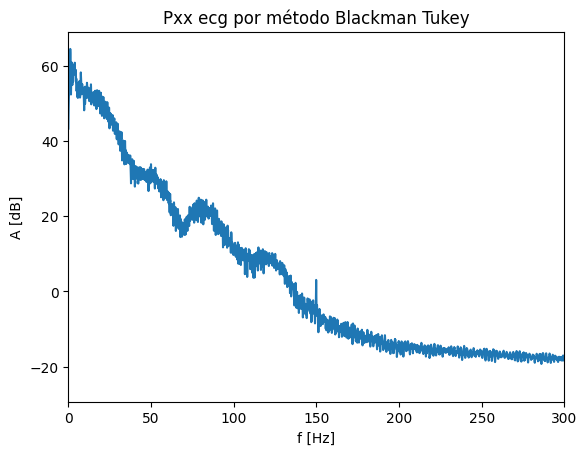

N de ppg: 44919


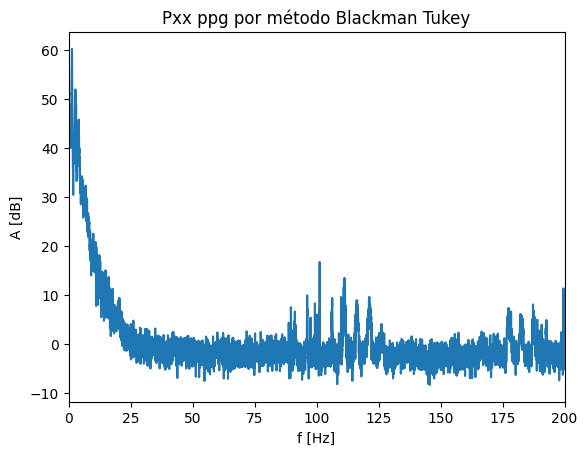

N de wav: 144000


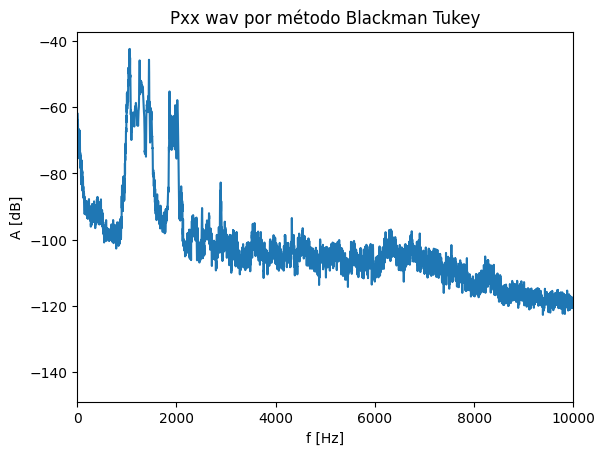

In [11]:
xlim = { "ecg":300, "ppg":200, "wav":10e3 }

for name, signal in signals.items():
    N = len(signal["data"])
    print(f"N de {name}: {N}")

    plt.figure()
    plt.title(f"Pxx {name} por método Blackman Tukey")
    
    f_, Pxx_ = my_blackman_tukey(signal["data"], fs=signal["fs"], nfft=2*N)
    signal["blackman"] = Pxx_
    signal["f_blackman"] = f_

    plt.plot(f_, 10*np.log10(Pxx_))
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")
    plt.show()


Se desconoce por qué la fórmula de Blackman Tukey falla cuando la señal presenta un valor de continua muy elevado. 

La señal se normalizó con respecto a la media para que esto no ocurra. Si no se hiciera esto, el ECG daría mal. El resto darían correctamente.

### Comparación de métodos

A continuación, se muestran los 3 gráficos uno al lado del otro para una comparación de resultados.

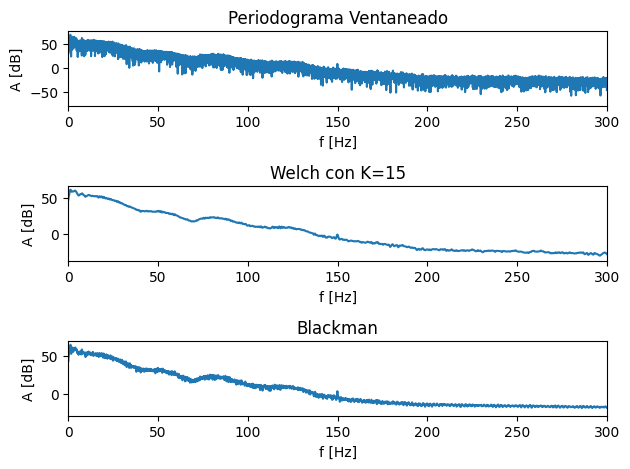

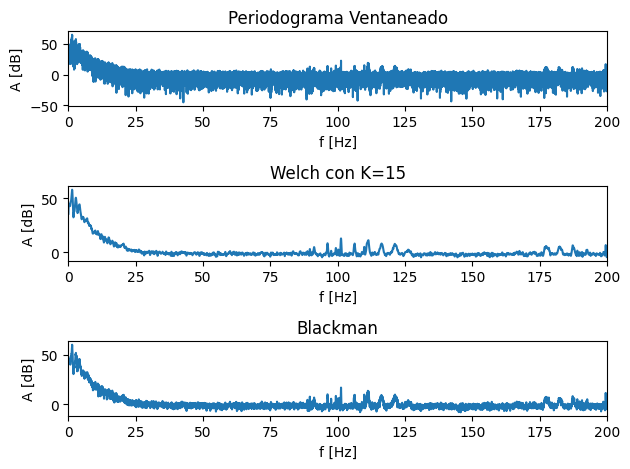

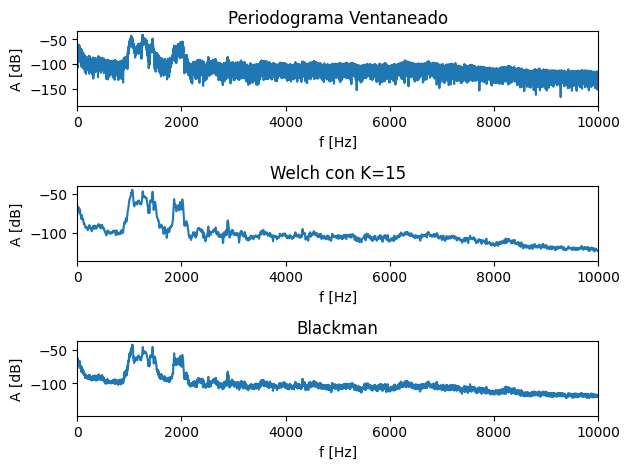

In [12]:
xlim = { "ecg":300, "ppg":200, "wav":10e3 }

for name, signal in signals.items():
    plt.figure()

    plt.subplot(3,1,1)
    plt.plot(signal["f_periodograma"], 10*np.log10(signal["periodograma"]))
    plt.title("Periodograma Ventaneado")
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")
    
    plt.subplot(3,1,2)
    plt.plot(signal["f_welch"], 10*np.log10(signal["welch"]))
    plt.title("Welch con K=15")
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")

    plt.subplot(3,1,3)
    plt.plot(signal["f_blackman"], 10*np.log10(signal["blackman"]))
    plt.title("Blackman")
    plt.xlim(0, xlim[name])
    plt.xlabel("f [Hz]")
    plt.ylabel("A [dB]")

    plt.tight_layout()
    plt.show()


### Estimación de Ancho de Banda

Se va a realizar una primera estimación del ancho de banda. Es importante destacar que estas señales no poseen ruido, por lo que puede dar peores resultados con ruido añadido.

Otra consideración es que estamos utilizando métodos no paramétricos. Eso quiere decir que "no conocemos" nada de la señal y el método es genérico para cualquier señal. 
Un método paramétrico supone cosas de la señal y permite modelos más precisos y ligeros aplicados para determinados problemas.

Se aclara esto último porque los ecg, ppg y la voz humana (el wav con música) todos presentan caractéristicas particulares que podrían parametrizarse.

Se estimará el ancho de banda de una señal pasabajos.
Se calculará como la integral de la señal Pxx. Se obtendrá el índice donde la Pxx no sea mayor que el margen que se busque

Para estimar el ancho de banda de una señal pasa banda se realizará una primer aproximación donde se supondrá que la energía se distribuye linealmente. De esta forma, si se limita un porcentaje X de energía, el resto de bandas tendrán una energía de 1-X. Como se distribuye linealmente, debajo de la frecuencia inferior habrá (1-X)/2 y por encima de la superior habrá (1-X)/2.

Esto no se cumple en la realidad y la aproximación no dará correctamente.

In [13]:
def est_bw(x, lim = .95):
    pot_acum = np.cumsum(x)
    pot_acum /= pot_acum[-1]
    idx = np.searchsorted(pot_acum, lim)
    
    return idx

def est_bw_bp(x, lim = .95):
    pot_acum = np.cumsum(x)
    pot_acum /= pot_acum[-1]

    idx_1 = np.searchsorted(pot_acum, ((1-lim)/2))
    idx_2 = np.searchsorted(pot_acum, ((1+lim)/2))

    return idx_1,  idx_2



========== ECG ==========
Periodograma        : 23.850 Hz


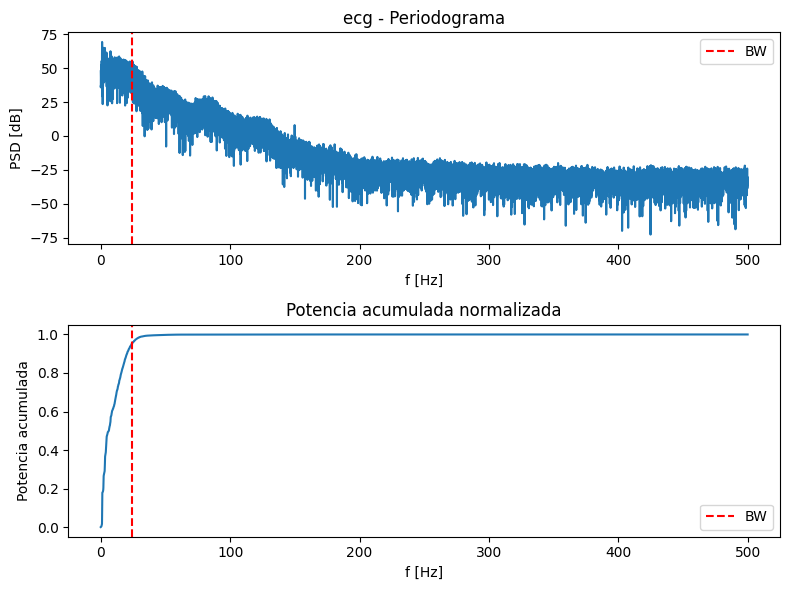

Welch               : 22.567 Hz


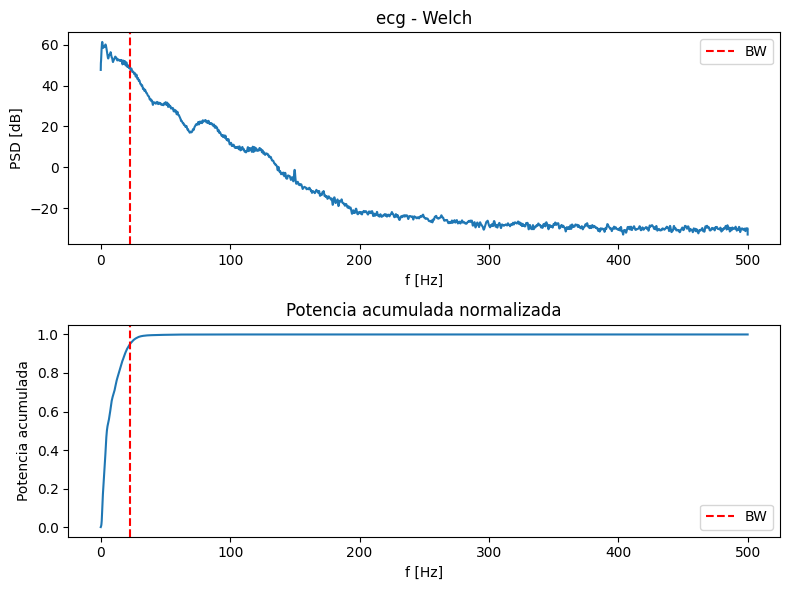

Blackman-Tukey      : 22.767 Hz


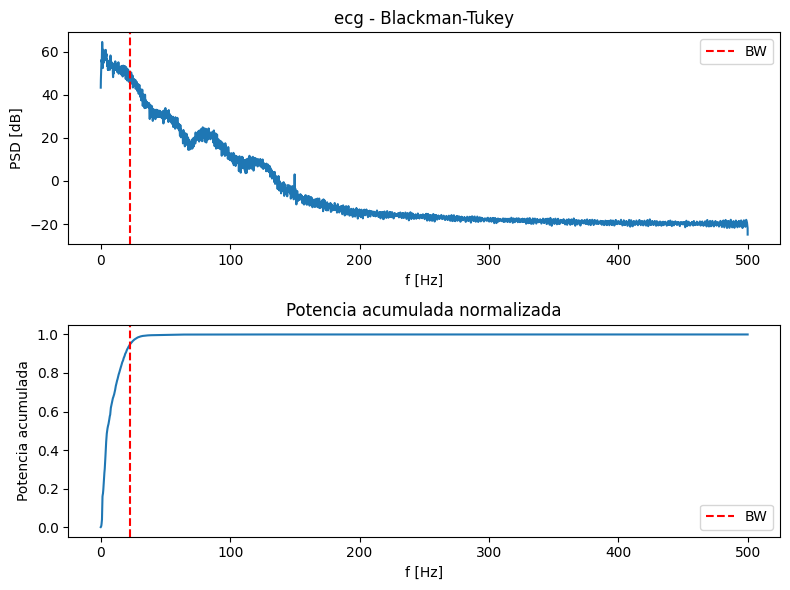


========== PPG ==========
Periodograma        : 3.989 Hz


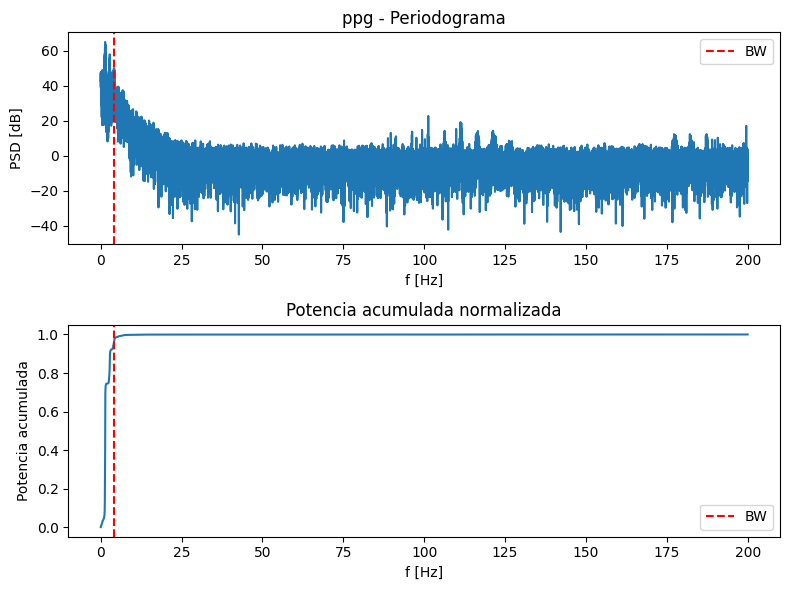

Welch               : 3.967 Hz


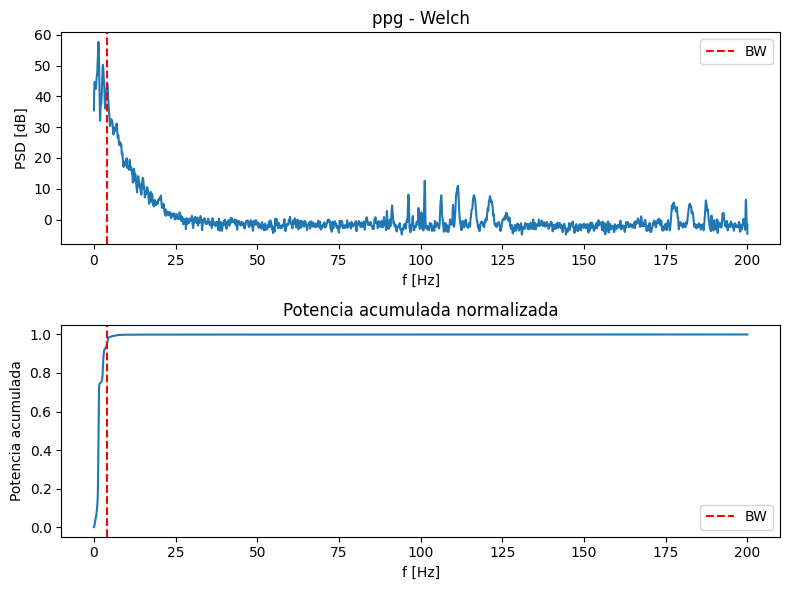

Blackman-Tukey      : 3.972 Hz


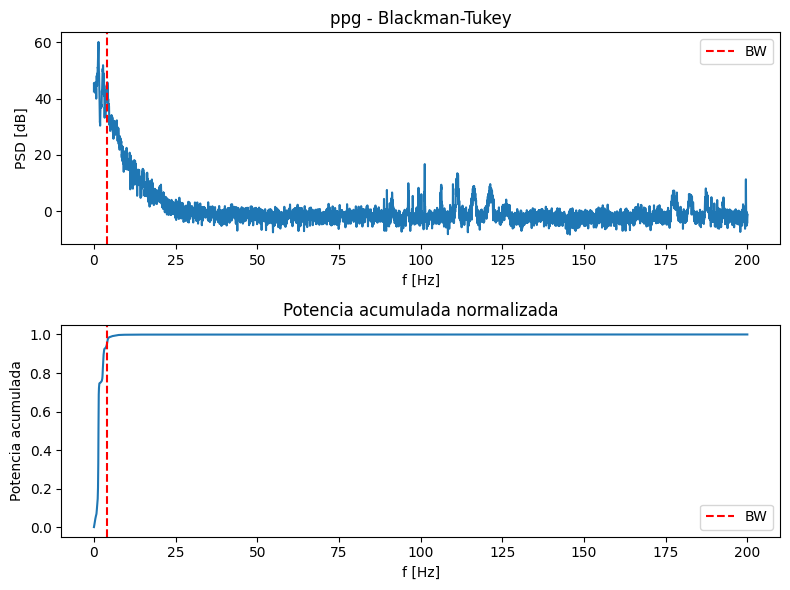


========== WAV ==========

Periodograma
f1 = 1011.000 Hz
f2 = 1979.333 Hz
BW = 968.333 Hz


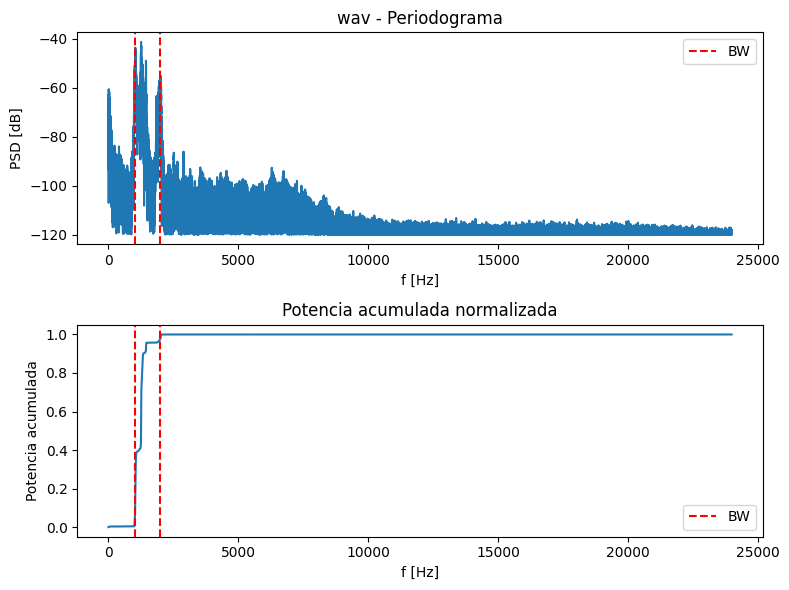


Welch
f1 = 1012.333 Hz
f2 = 1970.667 Hz
BW = 958.333 Hz


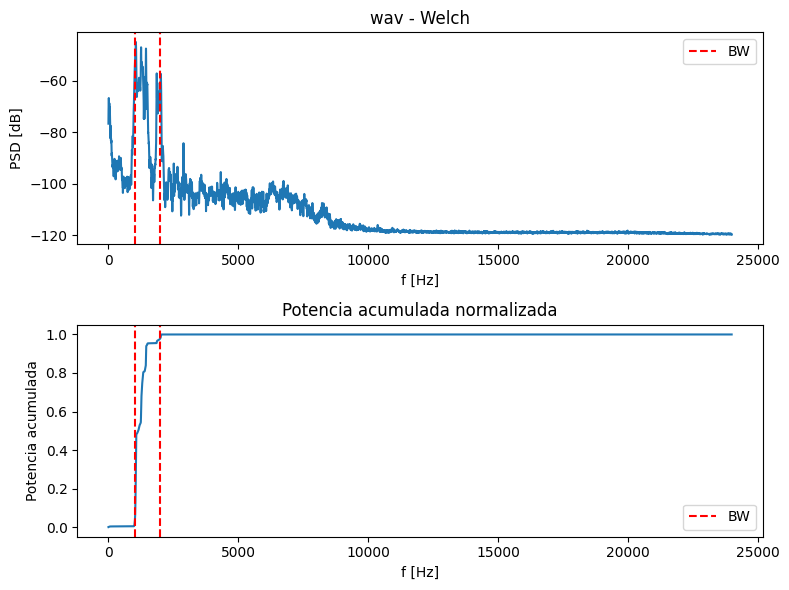


Blackman-Tukey
f1 = 1013.667 Hz
f2 = 1951.833 Hz
BW = 938.167 Hz


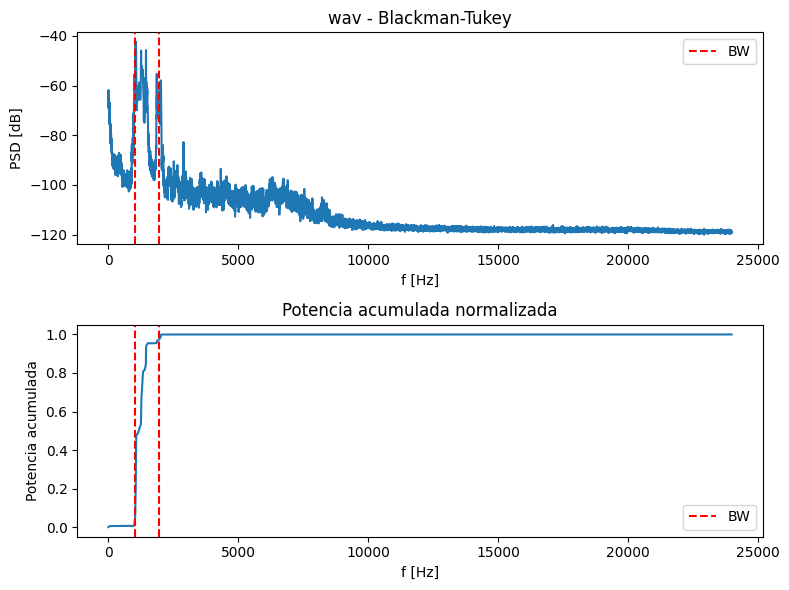

In [14]:
metodos = {
    "Periodograma": ("periodograma", "f_periodograma"),
    "Welch": ("welch", "f_welch"),
    "Blackman-Tukey": ("blackman", "f_blackman")
}

resultados = []

for name, signal in signals.items():
    print(f"\n========== {name.upper()} ==========")

    for metodo, (pxx_key, f_key) in metodos.items():
        Pxx = signal[pxx_key]
        f = signal[f_key]

        if name == "wav":
            idx1, idx2 = est_bw_bp(Pxx)

            f1 = f[idx1]
            f2 = f[idx2]
            bw = f2 - f1

            print(f"\n{metodo}")
            print(f"f1 = {f1:.3f} Hz")
            print(f"f2 = {f2:.3f} Hz")
            print(f"BW = {bw:.3f} Hz")

        else:
            idx_bw = est_bw(Pxx)
            bw = f[idx_bw]

            print(f"{metodo:<20}: {bw:.3f} Hz")

        resultados.append([name, metodo, bw])

        acumulado = np.cumsum(Pxx)
        acumulado /= acumulado[-1]

        plt.figure(figsize=(8,6))

        plt.subplot(2,1,1)
        plt.plot(f, 10*np.log10(Pxx + 1e-12))
        plt.title(f"{name} - {metodo}")
        plt.xlabel("f [Hz]")
        plt.ylabel("PSD [dB]")
        if name == "wav":
            plt.axvline(f1, color='r', linestyle='--')
            plt.axvline(f2, color='r', linestyle='--', label='BW')
        else:
            plt.axvline(bw, color='r', linestyle='--', label='BW')

        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(f, acumulado)
        plt.title("Potencia acumulada normalizada")
        plt.xlabel("f [Hz]")
        plt.ylabel("Potencia acumulada")
        if name == "wav":
            plt.axvline(f1, color='r', linestyle='--')
            plt.axvline(f2, color='r', linestyle='--', label='BW')
        else:
            plt.axvline(bw, color='r', linestyle='--', label='BW')
        plt.legend()

        plt.tight_layout()
        plt.show()

In [15]:
print("\n\nResumen de anchos de banda\n")

print(f"{'Señal':<15} | {'Método':<20} | {'BW [Hz]':>10}")
print("-" * 52)

for señal, metodo, bw in resultados:
    print(f"{señal:<15} | {metodo:<20} | {bw:>10.3f}")



Resumen de anchos de banda

Señal           | Método               |    BW [Hz]
----------------------------------------------------
ecg             | Periodograma         |     23.850
ecg             | Welch                |     22.567
ecg             | Blackman-Tukey       |     22.767
ppg             | Periodograma         |      3.989
ppg             | Welch                |      3.967
ppg             | Blackman-Tukey       |      3.972
wav             | Periodograma         |    968.333
wav             | Welch                |    958.333
wav             | Blackman-Tukey       |    938.167


## CONCLUSIONES

Se probaron empíricamente 3 métodos distintos para obtener el PSD de una señal. Además, se realizaron estimaciones de ancho de banda bastante certeras y con resultados similares con los 3 métodos.

Un comportamiento extraño que se observó es que tanto la función periodogram como welch de scipy no admiten el análisis de continua. Si una señal posee una continua añadida, esta desaparece y no tiene efecto en la transformación; y si se transformara una señal continua pura, se obtendría una salida de -120dB constante (No una delta ni nada parecido). 
Como las funciones de periodograma y blackman tucky no vienen de ninguna librería, se pudo observar esta diferencia claramente al comparar los 2 métodos. 

Se desconoce el motivo. Puede deberse a una normalización de la señal de entrada (visto como un proceso estadístico, Xnorm = (X - E(X))/var(X) )